# Python Quickstart — 5CTA0 Project

This is a short notebook that will help you get started with Python for the 5CTA0 project.
If you already know Python, you can skip this notebook and go straight to the project tasks.

For installing and setting up Python as well as this notebook, we refer you to the README.md file in the project repository.

After setting up:
- Run a cell with **Shift+Enter**. Variables carry over between cells.

Also useful:
- Each section ends with a *→ used in Task X* pointer.

## Contents
1. Running cells · 2. Imports · 3. Numbers & printing · 4. NumPy arrays ·
5. Slicing · 6. Booleans, masks & counting · 7. `np.where` & 2-D masks ·
8. Functions, lambdas & dicts · 9. Loops & comprehensions ·
10. The Gaussian (`scipy.stats.norm`) · 11. Fitting & linear algebra ·
12. Histograms & integration · 13. Signals (`scipy.signal`) ·
14. Plotting · 15. Resources

## 1. Running cells

Variables are **shared between cells** once you run them, top to bottom.

In [1]:
beats = 1981  # assign
print("beats =", beats)

beats = 1981


In [2]:
pvc = 444
print("PVC fraction:", pvc / beats)  # uses both variables

PVC fraction: 0.22412922766279655


Get help on anything with a trailing `?` (or `Shift+Tab` on the name).

In [3]:
# np.mean?      # uncomment and run to see the docs

## 2. Imports

`project.ipynb` already imports these for you. Here is what each is for.

In [4]:
import matplotlib.pyplot as plt  # plots
import numpy as np  # arrays + math (everything)
from scipy import signal  # matched filter, peaks, PSD (Parts 1-2)
from scipy.optimize import curve_fit  # least-squares curve fitting (Task 2.2)
from scipy.stats import norm  # the Gaussian: pdf / cdf / ppf (Parts 2-4)

rng = np.random.default_rng(0)  # reproducible random numbers

## 3. Numbers & printing

Arithmetic is what you'd expect (`**` = power, `%` = remainder, `/` = float divide).

In [5]:
samples, fs = 648000, 360  # 30-min ECG at 360 Hz
duration_h = samples / fs / 3600  # seconds -> hours
duration_h

0.5

**f-strings** format your reported numbers — you'll print a lot of these.

In [6]:
burden = 100 * 444 / 1981
print(f"PVC burden = {burden:.2f}%")  # 2 decimals
print(f"power      = {1.55e-4:.3e}")  # scientific notation
print(f"AUC        = {0.9989:.4f}")  # 4 decimals
# → Task 1.1 reports the burden exactly like this

PVC burden = 22.41%
power      = 1.550e-04
AUC        = 0.9989


## 4. NumPy arrays

Almost every quantity in the project is a NumPy array. Make one from a list:

In [7]:
rr = np.array([0.92, 0.88, 0.95, 0.60, 1.10, 0.90, 0.91])  # toy R-R intervals (s)
print(rr.shape, rr[0], rr[-1])

(7,) 0.92 0.91


Math is **element-wise and vectorised** (no loop needed):

In [8]:
print(rr * 1000)  # s -> ms, every element
print(60 / rr)  # instantaneous heart rate (bpm)

[ 920.  880.  950.  600. 1100.  900.  910.]
[ 65.2173913   68.18181818  63.15789474 100.          54.54545455
  66.66666667  65.93406593]


Summary statistics — note **`ddof`** (0 = population, 1 = sample / N−1):

In [9]:
print("mean :", np.mean(rr))
print("std0 :", np.std(rr))  # divides by N
print("std1 :", np.std(rr, ddof=1))  # divides by N-1  (SDNN uses this)
print("sum  :", np.sum(rr), " max:", np.max(rr))
# → Task 2.1: mean RR, SDNN (ddof=1), RMSSD

mean : 0.8942857142857144
std0 : 0.13792929274058638
std1 : 0.14898066349442166
sum  : 6.260000000000001  max: 1.1


`np.diff` gives successive differences; `argmax`/`argmin` give the index of the extreme.

In [10]:
d = np.diff(rr)  # rr[1:] - rr[:-1]
rmssd = np.sqrt(np.mean(d**2))  # root-mean-square of successive diffs
areas = np.array([100, 130, 128, 90, 85])
print("RMSSD:", rmssd, " ED frame:", np.argmax(areas), " ES frame:", np.argmin(areas))
# → Task 2.1 (RMSSD) and Task 4.1 (ED = argmax area, ES = argmin area)

RMSSD: 0.26429150572805027  ED frame: 1  ES frame: 4


## 5. Slicing

`a[start:stop]` (stop excluded), negative indices count from the end.

In [11]:
print(areas[:3])  # first 3 frames   -> near-ED
print(areas[-3:])  # last 3 frames    -> near-ES
W, k = 3, 5
print(rr[k - W : k])  # the W intervals ending just before beat k -> a "window"
# → Task 4.3 (first/last 3 frames) and Task 3.1 (sliding window of W intervals)

[100 130 128]
[128  90  85]
[0.95 0.6  1.1 ]


## 6. Booleans, masks & counting

A comparison on an array returns a **boolean mask**. `sum` counts `True`s; `mean` gives the **fraction** that are `True`.

In [12]:
short = rr < 0.7
print(short)  # [False ... True ...]
print("count   :", np.sum(short))  # how many
print("fraction:", np.mean(short))  # what fraction  (a probability!)

[False False False  True False False False]
count   : 1
fraction: 0.14285714285714285


That *fraction-below-a-threshold* is the key trick for detection rates and burdens.

In [13]:
gamma = 0.7
P_FA = np.mean(rr > gamma)  # fraction of (normal) values above a threshold
# → Task 3.2: P_FA = np.mean(feat_N < gamma), P_D = np.mean(feat_V < gamma)
print(P_FA)

0.8571428571428571


Combine masks with `&` (and) / `|` (or) — **wrap each comparison in brackets**:

In [14]:
mid = (rr > 0.8) & (rr < 1.0)
print(rr[mid])  # boolean indexing keeps only the True entries

[0.92 0.88 0.95 0.9  0.91]


## 7. `np.where` & 2-D masks

Echo masks are 2-D images of class labels. Count a class, or get pixel coordinates.

In [15]:
mask = np.array([[0, 1, 1, 0], [0, 1, 1, 0], [2, 2, 1, 0]])  # 0=bg, 1=LV cavity, 2=myocardium
print("LV area:", np.sum(mask == 1))  # pixels labelled 1
rows, cols = np.where(mask == 1)  # (row, col) of every LV pixel
print("centroid (row, col):", rows.mean(), cols.mean())
# → Task 4.1 (area = count of label==1) and Task 4.2 (centroids from np.where)

LV area: 5
centroid (row, col): 0.8 1.6


With a stack of frames, sum over the image axes to get an area per frame:

In [16]:
masks = rng.integers(0, 3, size=(5, 8, 8))  # toy (frames, H, W)
lv_areas = np.sum(masks == 1, axis=(1, 2))  # one number per frame
print(lv_areas)
# → Task 4.1: lv_areas = np.sum(masks == 1, axis=(1, 2))

[22 22 18 18 20]


## 8. Functions, lambdas & dicts

Define helpers with `def`; return one or more values.

In [17]:
def long_axis(rows, cols):
    """Euclidean distance between the two row-extremes of a mask."""
    apex = np.array([rows.max(), cols[rows.argmax()]])
    base = np.array([rows.min(), cols[rows.argmin()]])
    return np.linalg.norm(apex - base)


print(long_axis(rows, cols))
# → Task 4.2: you implement lv_long_axis_length() much like this

2.23606797749979


A **dict of lambdas** is a tidy way to try several candidate features (Task 3.1):

In [18]:
features = {
    "mean": lambda w: np.mean(w),
    "min": lambda w: np.min(w),
    "range": lambda w: np.max(w) - np.min(w),
}
for name, fn in features.items():
    print(f"{name:6s} -> {fn(rr):.3f}")

mean   -> 0.894
min    -> 0.600
range  -> 0.500


## 9. Loops & comprehensions

A **list comprehension** builds a list in one line: `[expr for x in iterable]`.

In [19]:
cubes = [x**3 for x in range(5)]
print(cubes)

[0, 1, 8, 27, 64]


Sweeping a threshold to build a curve is the comprehension you'll reuse most:

In [20]:
thresholds = np.linspace(rr.min(), rr.max(), 6)
pfa_curve = np.array([np.mean(rr > t) for t in thresholds])  # rate at each threshold
print(np.round(pfa_curve, 2))
# → Task 3.2: pfa_curve / pd_curve sweep; Task 2.3c: the AIC sweep over AR orders

[0.86 0.86 0.86 0.57 0.14 0.  ]


## 10. The Gaussian — `scipy.stats.norm`

`norm` is the normal distribution. Three methods do almost everything in Parts 2-4:

In [21]:
mu, sigma = 0.9, 0.04
print("pdf  :", norm.pdf(0.9, mu, sigma))  # density at a point (for plotting a fit)
print("cdf  :", norm.cdf(0.86, mu, sigma))  # P(X < 0.86)  -> detection prob / AUC
print("ppf  :", norm.ppf(0.10, mu, sigma))  # inverse cdf  -> threshold for a given P_FA

pdf  : 9.973557010035817
cdf  : 0.15865525393145685
ppf  : 0.848737937378216


Two project formulas built straight from these:

In [22]:
mu0, s0, mu1, s1 = 0.87, 0.03, 0.44, 0.05
auc = norm.cdf(abs(mu0 - mu1) / np.sqrt(s0**2 + s1**2))  # analytic AUC
gamma_np = mu0 + s0 * norm.ppf(0.10)  # NP threshold at P_FA=0.10
print(f"AUC = {auc:.3f}   gamma_NP = {gamma_np:.3f}")
# → Task 3.1 (AUC) and Task 3.2 (NP threshold)

AUC = 1.000   gamma_NP = 0.832


## 11. Fitting & linear algebra

`curve_fit` finds the parameters of a model that best match data (least squares).

In [23]:
def gaussian(x, mu, sigma):
    return norm.pdf(x, mu, sigma)


xd = np.linspace(0.7, 1.1, 40)
yd = norm.pdf(xd, 0.9, 0.05) + 0.05 * rng.standard_normal(40)  # noisy "histogram"
popt, _ = curve_fit(gaussian, xd, yd, p0=[0.9, 0.05])  # p0 = initial guess
print("fitted mu, sigma:", popt)
# → Task 2.2c: compare your Gauss-Newton fit against curve_fit

fitted mu, sigma: [0.89976289 0.05014797]


For the Gauss-Newton step you solve a linear system and check a vector length:

In [24]:
JtJ = np.array([[3.0, 1.0], [1.0, 2.0]])
Jte = np.array([9.0, 8.0])
delta = np.linalg.solve(JtJ, Jte)  # solve (JtJ) delta = Jte  -> the GN update
print("update:", delta, " size:", np.linalg.norm(delta))  # norm -> stop when small
# → Task 2.2b: delta = np.linalg.solve(J.T @ J, J.T @ eps)

update: [2. 3.]  size: 3.605551275463989


## 12. Histograms & integration

`np.histogram(..., density=True)` gives a normalised histogram; bin *centres* are handy.

In [25]:
counts, edges = np.histogram(rng.normal(0.9, 0.05, 2000), bins=15, density=True)
centres = 0.5 * (edges[:-1] + edges[1:])  # midpoints of each bin
print(centres.shape, counts.shape)
# → Task 2.2: fit a Gaussian to (centres, counts)

(15,) (15,)


`np.trapezoid` integrates (area under a curve) — used for band power and empirical AUC.

In [26]:
f = np.linspace(0, 0.5, 500)
psd = np.exp(-(((f - 0.1) / 0.03) ** 2))  # a fake spectral peak
band = (f >= 0.04) & (f <= 0.15)  # the LF band
lf_power = np.trapezoid(psd[band], f[band])  # integrate the PSD over the band
print(f"LF power = {lf_power:.4f}")
# → Task 2.3 (LF/HF band powers) and Task 3.2 (AUC = trapezoid of the ROC)

LF power = 0.0525


## 13. Signals — `scipy.signal`

**Matched filter (Task 1.3):** cross-correlate with a template, then pick peaks.

In [27]:
x = np.zeros(400)
x[[80, 170, 300]] = 1.0  # three "R-peaks"
x = x + 0.1 * rng.standard_normal(400)  # + noise
template = np.array([0.2, 1.0, 0.2])

y = signal.correlate(x - x.mean(), template, mode="same")  # matched-filter output
peaks, _ = signal.find_peaks(y, height=0.5, distance=20)  # threshold + min spacing
print("detected peaks at:", peaks)
# → Task 1.3: correlate(ecg_noisy - mean, qrs_template) then find_peaks(..., distance=...)

detected peaks at: [ 80 170 300]


**Power spectral density (Task 2.3):** `welch` (averaged) or `periodogram` (single).

In [28]:
t = np.arange(0, 20, 0.25)  # 4 Hz sampling
sig = np.sin(2 * np.pi * 0.1 * t) + 0.3 * rng.standard_normal(t.size)
freqs, pxx = signal.welch(sig, fs=4.0, nperseg=64)
print("peak frequency:", freqs[np.argmax(pxx)], "Hz")
# → Task 2.3b: signal.welch / signal.periodogram on the resampled R-R series

peak frequency: 0.0625 Hz


## 14. Plotting

Line + scatter, with labels and a legend:

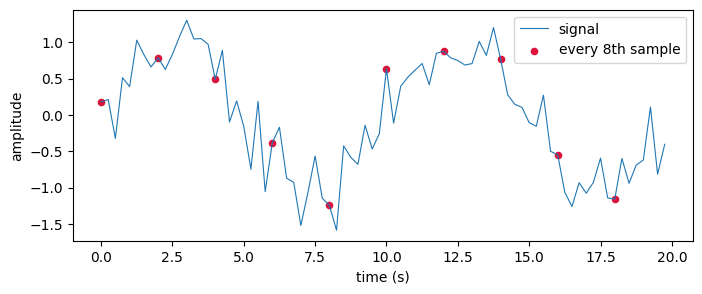

In [29]:
plt.figure(figsize=(8, 3))
plt.plot(t, sig, lw=0.8, label="signal")
plt.scatter(t[::8], sig[::8], color="crimson", s=20, label="every 8th sample")
plt.xlabel("time (s)")
plt.ylabel("amplitude")
plt.legend()
plt.show()

Several panels at once with `fig, axes = plt.subplots(...)` — the project's provided plots use this:

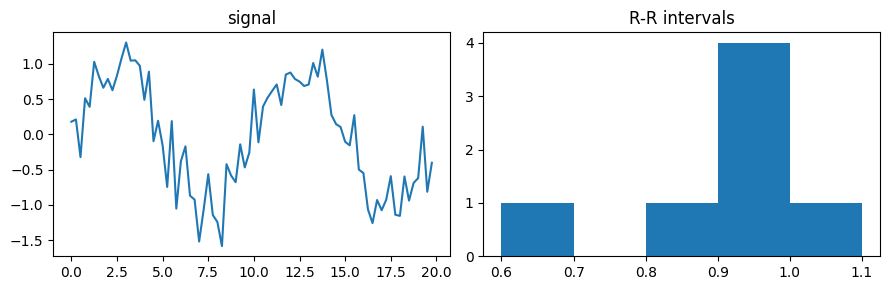

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))  # one row, two axes
axes[0].plot(t, sig)
axes[0].set_title("signal")
axes[1].hist(rr, bins=5)
axes[1].set_title("R-R intervals")
plt.tight_layout()
plt.show()

Histogram with a fitted curve on top (the Task 2.2 / 3.1 picture):

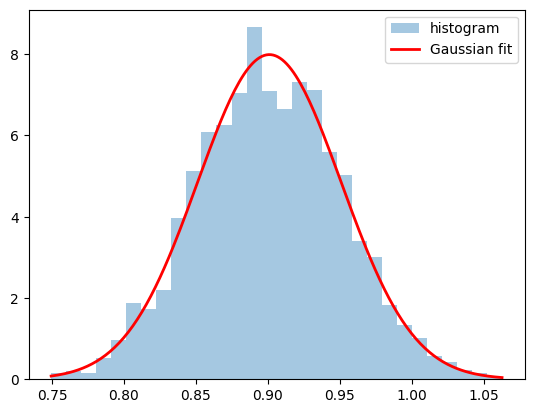

In [31]:
data = rng.normal(0.9, 0.05, 2000)
xs = np.linspace(data.min(), data.max(), 200)
plt.hist(data, bins=30, density=True, alpha=0.4, label="histogram")
plt.plot(xs, norm.pdf(xs, data.mean(), data.std()), "r-", lw=2, label="Gaussian fit")
plt.legend()
plt.show()

Log-y spectrum with shaded bands (the Task 2.3 PSD plot):

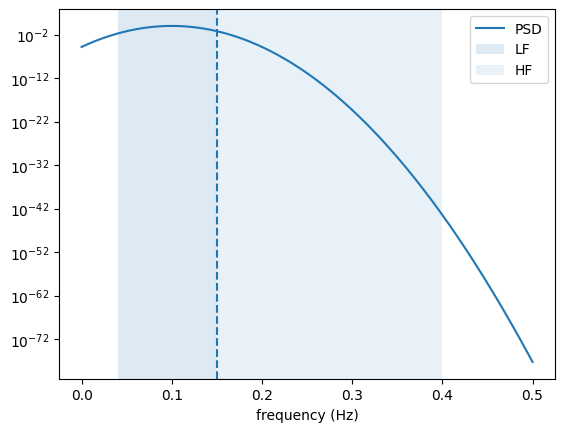

In [32]:
plt.semilogy(f, psd, label="PSD")
plt.axvspan(0.04, 0.15, alpha=0.15, label="LF")  # shade a band
plt.axvspan(0.15, 0.40, alpha=0.10, label="HF")
plt.axvline(0.15, ls="--")  # mark a boundary
plt.xlabel("frequency (Hz)")
plt.legend()
plt.show()

Show an image / mask with `imshow` (the echo frames in Part 4):

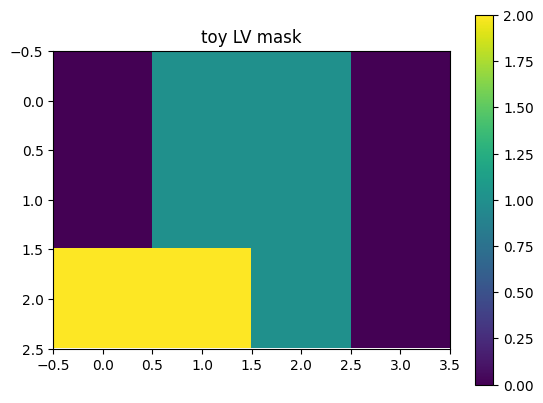

In [33]:
plt.imshow(mask, cmap="viridis")
plt.title("toy LV mask")
plt.colorbar()
plt.show()

## 15. Resources

- NumPy: <https://numpy.org/doc/stable/>
- SciPy signal: <https://docs.scipy.org/doc/scipy/reference/signal.html>
- Matplotlib: <https://matplotlib.org/stable/gallery/index.html>

When stuck on a function, run `name?` in a cell, or read the `# 📋` hint comments
right above each `🧠 Your solution` block in `project.ipynb`. Good luck with the project assignment!